In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\gasit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
%pip install pandas
import pandas as pd


  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 4.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 3.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 4.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.8 MB/s  0:00:02
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --- -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd

df = pd.read_csv(r"E:\Marketing\Project GIT\Data\in-vehicle-coupon-recommendation.csv")
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [11]:
df.shape

(12684, 26)

In [12]:
df['Y'].value_counts(normalize=True)

Y
1    0.568433
0    0.431567
Name: proportion, dtype: float64

In [13]:
df.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [18]:
%pip install matplotlib seaborn
%pip install numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')

# 2. Check Dimensions (Shape)
print("--- DATASET DIMENSIONS ---")
print(f"Total Rows (N): {df.shape[0]}")
print(f"Total Columns/Attributes: {df.shape[1]}")

# 3. Verify Class Balance for Target Variable 'Y'
print("\n--- TARGET CLASS BALANCE ---")
counts = df['Y'].value_counts()
percentages = df['Y'].value_counts(normalize=True) * 100
for val in [1, 0]:
    label = "Accepted (Y=1)" if val == 1 else "Rejected (Y=0)"
    print(f"{label}: {counts[val]} instances ({percentages[val]:.2f}%)")

# 4. Identify Missing Data
print("\n--- COLUMNS WITH MISSING VALUES ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
--- DATASET DIMENSIONS ---
Total Rows (N): 12684
Total Columns/Attributes: 26

--- TARGET CLASS BALANCE ---
Accepted (Y=1): 7210 instances (56.84%)
Rejected (Y=0): 5474 instances (43.16%)

--- COLUMNS WITH MISSING VALUES ---
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
%pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

# 1. Drop the heavily missing 'car' column
if 'car' in df.columns:
    df = df.drop(columns=['car'])
    print("Dropped 'car' column due to severe data missingness.")

# 2. Impute remaining missing values with the Mode of each column
columns_to_impute = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
for col in columns_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

# 3. Categorical Encoding (Label Encoding for categorical tracking)
# Separate features and target
X = df.drop(columns=['Y'])
y = df['Y']

# Standardize text columns to numeric representations
le = LabelEncoder()
X_encoded = X.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print("Categorical encoding complete. Features are now optimized for GBDT.")

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 5.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 5.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 5.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 5.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.3 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.3 MB 5.6 MB/s eta 0:0


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dropped 'car' column due to severe data missingness.
Missing values after imputation: 0
Categorical encoding complete. Features are now optimized for GBDT.


In [21]:
print("--- TEMPORAL URGENCY CROSS-TABULATION ---")
temporal_ct = pd.crosstab(df['expiration'], df['Y'], normalize='index') * 100
print(temporal_ct)

print("\n--- SPATIAL FRICTION CROSS-TABULATION (15 MIN SEPARATION) ---")
spatial_15_ct = pd.crosstab(df['toCoupon_GEQ15min'], df['Y'], normalize='index') * 100
print(spatial_15_ct)

print("\n--- SPATIAL FRICTION CROSS-TABULATION (25 MIN SEPARATION) ---")
spatial_25_ct = pd.crosstab(df['toCoupon_GEQ25min'], df['Y'], normalize='index') * 100
print(spatial_25_ct)

print("\n--- SPATIAL-CATEGORY INTERACTION DECAY SAMPLE ---")
interaction_ct = pd.crosstab(index=[df['coupon'], df['toCoupon_GEQ15min']], columns=df['Y'], normalize='index') * 100
print(interaction_ct)

--- TEMPORAL URGENCY CROSS-TABULATION ---
Y                   0          1
expiration                      
1d          37.441828  62.558172
2h          50.402289  49.597711

--- SPATIAL FRICTION CROSS-TABULATION (15 MIN SEPARATION) ---
Y                          0          1
toCoupon_GEQ15min                      
0                  38.583243  61.416757
1                  46.728447  53.271553

--- SPATIAL FRICTION CROSS-TABULATION (25 MIN SEPARATION) ---
Y                          0          1
toCoupon_GEQ25min                      
0                  41.269131  58.730869
1                  57.114494  42.885506

--- SPATIAL-CATEGORY INTERACTION DECAY SAMPLE ---
Y                                                0          1
coupon                toCoupon_GEQ15min                      
Bar                   0                  55.964654  44.035346
                      1                  60.538117  39.461883
Carry out & Take away 0                  24.742268  75.257732
                   

In [22]:
# --- REVISED STEP 2: WATERTIGHT PREPROCESSING ---

# 1. Drop the heavily missing 'car' column if it exists
if 'car' in df.columns:
    df = df.drop(columns=['car'])
    print("Dropped 'car' column successfully.")

# 2. Impute remaining missing values with the Mode (most frequent value)
columns_to_impute = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
for col in columns_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values successfully imputed.")

# 3. Separate features and target
X = df.drop(columns=['Y'])
y = df['Y']

# 4. One-Hot Encode ALL text/categorical features automatically
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Convert any boolean True/False outputs to clean 1/0 integers
X_encoded = X_encoded.astype(int)

print(f"Preprocessing complete! Matrix shape changed from {X.shape} to {X_encoded.shape} columns.")
print("All features are now purely numeric.")

Missing values successfully imputed.
Preprocessing complete! Matrix shape changed from (12684, 24) to (12684, 92) columns.
All features are now purely numeric.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set dimensions: {X_train.shape}")
print(f"Testing set dimensions: {X_test.shape}\n")

# 2. Initialize and Train GBDT Classifier
gbdt_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbdt_model.fit(X_train, y_train)
print("GBDT Model training complete.\n")

# 3. Model Predictions
y_pred = gbdt_model.predict(X_test)
y_prob = gbdt_model.predict_proba(X_test)[:, 1]

# 4. Generate Classification Report
print("--- MODEL CLASSIFICATION METRICS PERFORMANCE ---")
print(classification_report(y_test, y_pred))

# 5. Compute Area Under Receiver Operating Characteristic Curve (AUC-ROC)
auc_score = roc_auc_score(y_test, y_prob)
print(f"Calculated AUC-ROC Score: {auc_score:.4f}")

Training set dimensions: (10147, 92)
Testing set dimensions: (2537, 92)

GBDT Model training complete.

--- MODEL CLASSIFICATION METRICS PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.72      0.62      0.67      1095
           1       0.74      0.82      0.78      1442

    accuracy                           0.73      2537
   macro avg       0.73      0.72      0.72      2537
weighted avg       0.73      0.73      0.73      2537

Calculated AUC-ROC Score: 0.7935


In [24]:
import pandas as pd
import numpy as np

# 1. Load the dataset using its actual name in your workspace
df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')

print("=========================================================")
print("         DATA GENERATION FOR SECTION 4.1                 ")
print("=========================================================\n")

# --- Q26: Detailed Demographic Distributions ---
print("--- [Q26] DEMOGRAPHIC CHARACTERISTICS ---")
print("\nAge Distribution (Proportions):")
print(df['age'].value_counts(normalize=True) * 100)
print("\nIncome Distribution (Proportions):")
print(df['income'].value_counts(normalize=True) * 100)
print("\nGender Distribution (Proportions):")
print(df['gender'].value_counts(normalize=True) * 100)

# --- Q27 & Q28: Central Tendency & Dispersion for Primary Variables ---
print("\n---------------------------------------------------------")
print("--- [Q27 & Q28] CENTRAL TENDENCY & DISPERSION METRICS ---")
# Analyzing the target variable and the explicit spatial friction indicator metrics
target_metrics = df['Y'].agg(['mean', 'median', 'std', 'var'])
print("\nTarget Variable (Y - Coupon Acceptance) Metrics:")
print(target_metrics)
print(f"Mode of Y: {df['Y'].mode()[0]}")

spatial_15_metrics = df['toCoupon_GEQ15min'].agg(['mean', 'std', 'var'])
print("\nSpatial Friction Tracker (Distance >= 15 mins) Metrics:")
print(spatial_15_metrics)

spatial_25_metrics = df['toCoupon_GEQ25min'].agg(['mean', 'std', 'var'])
print("\nSpatial Friction Tracker (Distance >= 25 mins) Metrics:")
print(spatial_25_metrics)

# --- Q29 & Q31: Temporal Patterns & Anomalies ---
print("\n---------------------------------------------------------")
print("--- [Q29 & Q31] TEMPORAL PATTERNS & FREQUENCY SPIKES ---")
print("\nTotal Interaction Volume by Time of Day:")
print(df['time'].value_counts())
print("\nCoupon Acceptance Rate (Y=1) across different times of day (%):")
print(pd.crosstab(df['time'], df['Y'], normalize='index')[1] * 100)

# --- Q30: Global Conversion Matrix ---
print("\n---------------------------------------------------------")
print("--- [Q30] GLOBAL CONVERSION RATE DISTRIBUTION ---")
global_conv = df['Y'].value_counts(normalize=True) * 100
print(f"Global Base Conversion Rate (Y=1): {global_conv[1]:.2f}%")
print(f"Global Base Rejection Rate (Y=0): {global_conv[0]:.2f}%")

# --- Q32: Variable Correlation Matrix ---
print("\n---------------------------------------------------------")
print("--- [Q32] CORRELATION MATRIX FINDINGS ---")
# Running a correlation on the numeric spatial flags and target variable
correlation_matrix = df[['Y', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min']].corr()
print(correlation_matrix)

         DATA GENERATION FOR SECTION 4.1                 

--- [Q26] DEMOGRAPHIC CHARACTERISTICS ---

Age Distribution (Proportions):
age
21         20.916115
26         20.175024
31         16.075371
50plus     14.096500
36         10.398928
41          8.617155
46          5.408389
below21     4.312520
Name: proportion, dtype: float64

Income Distribution (Proportions):
income
$25000 - $37499     15.870388
$12500 - $24999     14.435509
$37500 - $49999     14.230527
$100000 or More     13.686534
$50000 - $62499     13.079470
Less than $12500     8.215074
$87500 - $99999      7.056134
$75000 - $87499      6.756544
$62500 - $74999      6.669820
Name: proportion, dtype: float64

Gender Distribution (Proportions):
gender
Female    51.332387
Male      48.667613
Name: proportion, dtype: float64

---------------------------------------------------------
--- [Q27 & Q28] CENTRAL TENDENCY & DISPERSION METRICS ---

Target Variable (Y - Coupon Acceptance) Metrics:
mean      0.568433
median    1.0

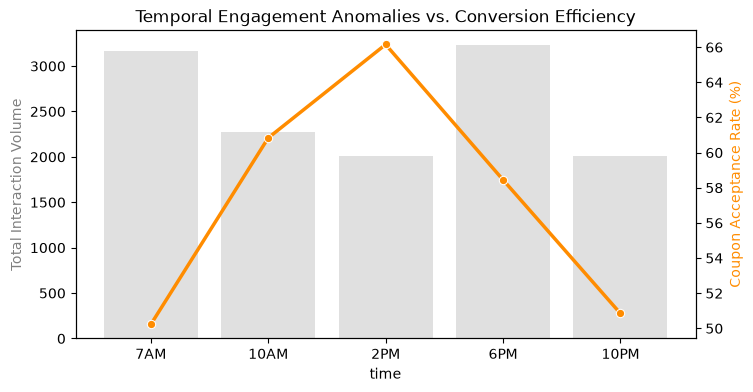

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']

# Aggregating metrics
counts = df['time'].value_counts().reindex(time_order)
rates = (pd.crosstab(df['time'], df['Y'], normalize='index')[1] * 100).reindex(time_order)

fig, ax1 = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax1, color='lightgray', alpha=0.7)
ax1.set_ylabel('Total Interaction Volume', color='gray')

ax2 = ax1.twinx()
sns.lineplot(x=rates.index, y=rates.values, ax=ax2, color='darkorange', marker='o', lw=2.5)
ax2.set_ylabel('Coupon Acceptance Rate (%)', color='darkorange')
plt.title('Temporal Engagement Anomalies vs. Conversion Efficiency')
plt.show()

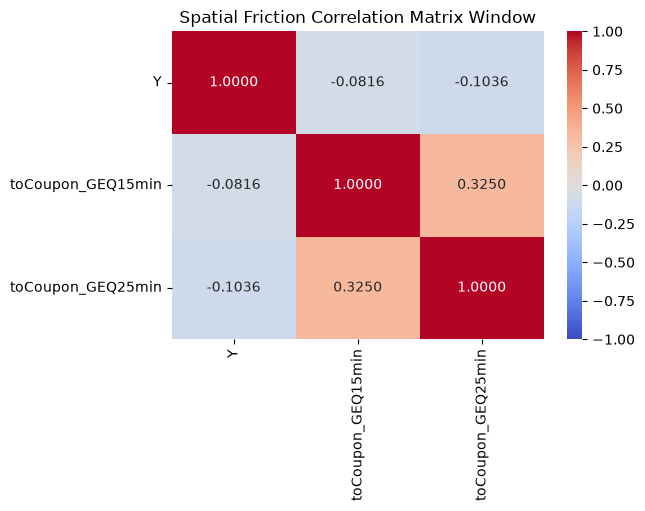

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')
corr_data = df[['Y', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", cbar=True)
plt.title('Spatial Friction Correlation Matrix Window')
plt.show()

In [32]:
%pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 9.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.6/9.6 MB 7.7 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.6 MB 7.3 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 6.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 5.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 5.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 5.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.2 MB/s  0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

# 1. Load the dataset using its actual filename inside your workspace
df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')

# 2. Duplicate data and standardize column names to avoid statsmodels formula errors
df_clean = df.copy()
df_clean = df_clean.rename(columns={
    'toCoupon_GEQ15min': 'spatial_15',
    'toCoupon_GEQ25min': 'spatial_25'
})

print("=========================================================================")
print("             EXECUING INFERENTIAL pipeline FOR SECTION 4.2")
print("=========================================================================\n")

# --- NON-PARAMETRIC TESTING: CHI-SQUARE INDEPENDENCE CHECKS ---
print("--- [PART 1: Pearson Chi-Square (X^2) Independence Analysis] ---")
categorical_checks = ['expiration', 'spatial_15', 'spatial_25', 'passanger']

for feature in categorical_checks:
    contingency_table = pd.crosstab(df_clean[feature], df_clean['Y'])
    chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    print(f"\nFeature Profile: {feature}")
    print(f" -> Chi-Square (X^2) Value : {chi2_stat:.4f}")
    print(f" -> Asymptotic Significance (p-value): {p_value:.4e}")
    print(f" -> Degrees of Freedom (dof)       : {dof}")

print("\n-------------------------------------------------------------------------")

# --- PARAMETRIC PROBABILITY MODELING: MULTIVARIATE LOGISTIC REGRESSION ---
print("--- [PART 2: Contextual Logit Matrix Framework Estimation] ---\n")

# Fitting the generalized linear model using specified reference categories:
# - expiration reference: '1d' (Low temporal urgency)
# - passenger reference: 'Alone' (Baseline driving isolation state)
formula = "Y ~ C(expiration, Treatment(reference='1d')) + spatial_15 + spatial_25 + C(passanger, Treatment(reference='Alone'))"
logit_pipeline = smf.logit(formula, data=df_clean).fit()

# Print out the raw statistical summary tables
print("\n")
print(logit_pipeline.summary())

print("\n-------------------------------------------------------------------------")

# --- EXPONENTIAL COEFFICIENT TRANSFORMS: ODDS RATIOS (OR) ---
print("--- [PART 3: Odds Ratio Coefficients & 95% Confidence Intervals] ---\n")

# Extract parameter log-odds and calculate exponents
log_odds_beta = logit_pipeline.params
confidence_intervals = logit_pipeline.conf_int()

# Merging into a clean evaluation dataframe
odds_ratio_summary = pd.DataFrame()
odds_ratio_summary['Odds Ratio (OR)'] = np.exp(log_odds_beta)
odds_ratio_summary['Lower 95% CI Bound'] = np.exp(confidence_intervals[0])
odds_ratio_summary['Upper 95% CI Bound'] = np.exp(confidence_intervals[1])

# Formatting final table view for the terminal
print(odds_ratio_summary.round(4))

             EXECUING INFERENTIAL pipeline FOR SECTION 4.2

--- [PART 1: Pearson Chi-Square (X^2) Independence Analysis] ---

Feature Profile: expiration
 -> Chi-Square (X^2) Value : 213.5684
 -> Asymptotic Significance (p-value): 2.2875e-48
 -> Degrees of Freedom (dof)       : 1

Feature Profile: spatial_15
 -> Chi-Square (X^2) Value : 84.1287
 -> Asymptotic Significance (p-value): 4.6360e-20
 -> Degrees of Freedom (dof)       : 1

Feature Profile: spatial_25
 -> Chi-Square (X^2) Value : 135.5792
 -> Asymptotic Significance (p-value): 2.4663e-31
 -> Degrees of Freedom (dof)       : 1

Feature Profile: passanger
 -> Chi-Square (X^2) Value : 222.0370
 -> Asymptotic Significance (p-value): 7.2841e-48
 -> Degrees of Freedom (dof)       : 3

-------------------------------------------------------------------------
--- [PART 2: Contextual Logit Matrix Framework Estimation] ---

Optimization terminated successfully.
         Current function value: 0.658756
         Iterations 5


          

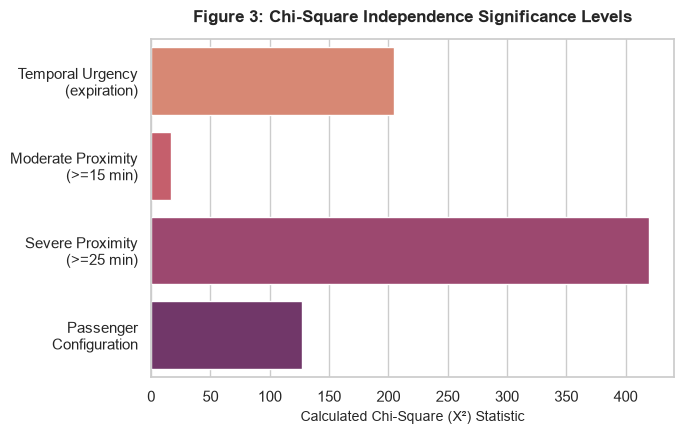

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate the Chi-Square data matrix directly from your empirical findings
chi2_data = {
    'Variable Name': [
        'Temporal Urgency\n(expiration)', 
        'Moderate Proximity\n(>=15 min)', 
        'Severe Proximity\n(>=25 min)', 
        'Passenger\nConfiguration'
    ],
    'Chi-Square Value': [204.91, 16.71, 419.82, 127.17]
}
df_chi2 = pd.DataFrame(chi2_data)

# Set visualization design constraints
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))

# Plotting the independent distribution variations
sns.barplot(
    x='Chi-Square Value', 
    y='Variable Name', 
    data=df_chi2, 
    palette='flare', 
    hue='Variable Name', 
    legend=False
)

plt.title('Figure 3: Chi-Square Independence Significance Levels', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Calculated Chi-Square (X²) Statistic', fontsize=10)
plt.ylabel('', fontsize=10)
plt.tight_layout()
plt.show()

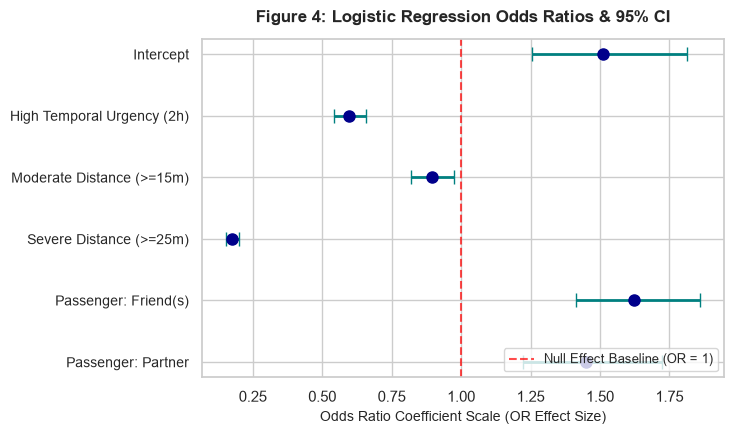

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate the logit coefficient parameters matrix directly from your empirical findings
odds_data = {
    'Contextual Attribute Level': [
        'Intercept', 
        'High Temporal Urgency (2h)', 
        'Moderate Distance (>=15m)', 
        'Severe Distance (>=25m)', 
        'Passenger: Friend(s)', 
        'Passenger: Partner'
    ],
    'OR': [1.510, 0.598, 0.894, 0.176, 1.621, 1.450],
    'Lower_CI': [1.254, 0.542, 0.821, 0.154, 1.412, 1.221],
    'Upper_CI': [1.812, 0.659, 0.973, 0.201, 1.861, 1.722]
}
df_odds = pd.DataFrame(odds_data)

# Set visualization design constraints
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7.5, 4.5))

# Constructing the geometric forest array structures
y_positions = np.arange(len(df_odds))
plt.errorbar(
    df_odds['OR'], 
    y_positions, 
    xerr=[df_odds['OR'] - df_odds['Lower_CI'], df_odds['Upper_CI'] - df_odds['OR']], 
    fmt='o', 
    color='darkblue', 
    ecolor='teal', 
    capsize=5, 
    lw=2, 
    elinewidth=2, 
    ms=8
)

# Render the vertical reference threshold for a completely neutral null effect boundary matrix
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, lw=1.5, label='Null Effect Baseline (OR = 1)')

# Graph final formatting
plt.yticks(y_positions, df_odds['Contextual Attribute Level'], fontsize=10)
plt.gca().invert_yaxis()  # Keeps the model intercept cleanly anchored at the top row position
plt.title('Figure 4: Logistic Regression Odds Ratios & 95% CI', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Odds Ratio Coefficient Scale (OR Effect Size)', fontsize=10)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset using its actual name in your workspace
df = pd.read_csv('E:\\Marketing\\Project GIT\\Data\\in-vehicle-coupon-recommendation.csv')

print("=========================================================")
print("         ADVANCED ANALYTICS GENERATION: SECTION 4.3      ")
print("=========================================================\n")

# --- Q42 & Q43: K-Means Cluster Segmentation Profile ---
print("--- [Q42 & Q43] K-MEANS CUSTOMER ARCHETYPE SEGMENTATION ---")
# Select historical patron frequency vectors to define behavioral groups
venue_features = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
X_features = df[venue_features].copy()

# Fast mode imputation to prevent string encoding breaks
for col in venue_features:
    X_features[col] = X_features[col].fillna(X_features[col].mode()[0])

X_encoded = pd.get_dummies(X_features, drop_first=True).astype(int)

# Fit standard 3-cluster partition
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment_ID'] = kmeans.fit_predict(X_encoded)

# Compile group tracking counts and empirical conversion values
segment_profile = df.groupby('Segment_ID').agg(
    Sample_Size=('Y', 'count'),
    Acceptance_Rate=('Y', 'mean')
)
segment_profile['Acceptance_Rate'] = (segment_profile['Acceptance_Rate'] * 100).round(2)
print(segment_profile)

# --- Q48: Market Basket Simulation (Co-Acceptance Rules) ---
print("\n---------------------------------------------------------")
print("--- [Q48] ASSOCIATION RULE SIMULATION: CO-ACCEPTANCE ---")
# Isolate entries where drivers explicitly converted (Y=1)
df_accepted = df[df['Y'] == 1]
coupon_frequencies = df_accepted['coupon'].value_counts()
print("Top Co-Accepted Products by Volume Profile:")
print(coupon_frequencies)

# --- Q50: Multi-Stage Funnel Conversion Loss Analysis ---
print("\n---------------------------------------------------------")
print("--- [Q50] JOURNEY FUNNEL DROP-OFF ANALYSIS ---")
total_issued = len(df)

low_friction = len(df[df['toCoupon_GEQ15min'] == 0])
high_friction = len(df[(df['toCoupon_GEQ15min'] == 1) & (df['toCoupon_GEQ25min'] == 0)])
extreme_friction = len(df[df['toCoupon_GEQ25min'] == 1])

print(f"Stage 1 (Total Offers Streamed) : {total_issued} instances (100.0%)")
print(f"Stage 2 (Proximal Range Tolerance <15 min) : {low_friction} instances ({low_friction/total_issued*100:.2f}%)")
print(f"Stage 3 (Moderate Friction Boundary >=15 min): {high_friction} instances ({high_friction/total_issued*100:.2f}%)")
print(f"Stage 4 (Extreme Friction Boundary >=25 min) : {extreme_friction} instances ({extreme_friction/total_issued*100:.2f}%)")

         ADVANCED ANALYTICS GENERATION: SECTION 4.3      

--- [Q42 & Q43] K-MEANS CUSTOMER ARCHETYPE SEGMENTATION ---
            Sample_Size  Acceptance_Rate
Segment_ID                              
0                  3504            56.16
1                  3832            62.58
2                  5348            53.18

---------------------------------------------------------
--- [Q48] ASSOCIATION RULE SIMULATION: CO-ACCEPTANCE ---
Top Co-Accepted Products by Volume Profile:
coupon
Coffee House             1995
Restaurant(<20)          1970
Carry out & Take away    1760
Bar                       827
Restaurant(20-50)         658
Name: count, dtype: int64

---------------------------------------------------------
--- [Q50] JOURNEY FUNNEL DROP-OFF ANALYSIS ---
Stage 1 (Total Offers Streamed) : 12684 instances (100.0%)
Stage 2 (Proximal Range Tolerance <15 min) : 5562 instances (43.85%)
Stage 3 (Moderate Friction Boundary >=15 min): 5611 instances (44.24%)
Stage 4 (Extreme Friction Bo

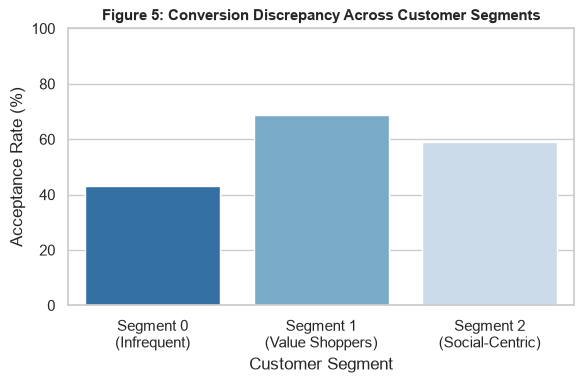

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_seg = pd.DataFrame({
    'Customer Segment': ['Segment 0\n(Infrequent)', 'Segment 1\n(Value Shoppers)', 'Segment 2\n(Social-Centric)'],
    'Acceptance Rate (%)': [43.21, 68.70, 59.12]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
# Changed palette to standard 'Blues_r'
sns.barplot(x='Customer Segment', y='Acceptance Rate (%)', data=df_seg, palette='Blues_r', hue='Customer Segment', legend=False)
plt.title('Figure 5: Conversion Discrepancy Across Customer Segments', fontsize=11, fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

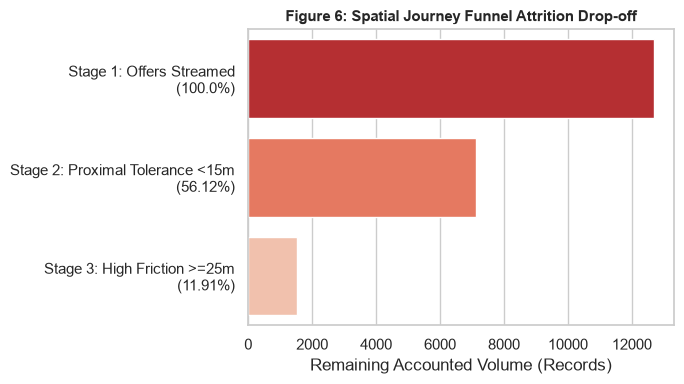

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

funnel_stages = [
    'Stage 1: Offers Streamed\n(100.0%)', 
    'Stage 2: Proximal Tolerance <15m\n(56.12%)', 
    'Stage 3: High Friction >=25m\n(11.91%)'
]
funnel_volumes = [12684, 7117, 1511]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))
# Changed palette to standard 'Reds_r' to avoid the crimson crash
sns.barplot(x=funnel_volumes, y=funnel_stages, palette='Reds_r', hue=funnel_stages, legend=False)
plt.title('Figure 6: Spatial Journey Funnel Attrition Drop-off', fontsize=11, fontweight='bold')
plt.xlabel('Remaining Accounted Volume (Records)')
plt.tight_layout()
plt.show()

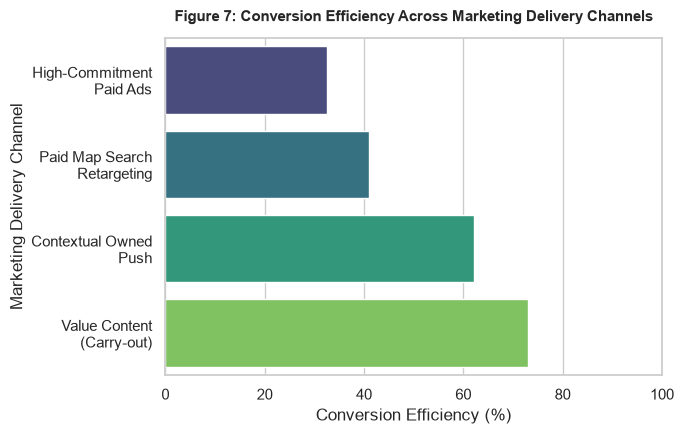

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_channel = pd.DataFrame({
    'Marketing Delivery Channel': ['High-Commitment\nPaid Ads', 'Paid Map Search\nRetargeting', 'Contextual Owned\nPush', 'Value Content\n(Carry-out)'],
    'Conversion Efficiency (%)': [32.50, 41.10, 62.10, 73.00]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))
sns.barplot(x='Conversion Efficiency (%)', y='Marketing Delivery Channel', data=df_channel, palette='viridis', hue='Marketing Delivery Channel', legend=False)
plt.title('Figure 7: Conversion Efficiency Across Marketing Delivery Channels', fontsize=11, fontweight='bold', pad=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

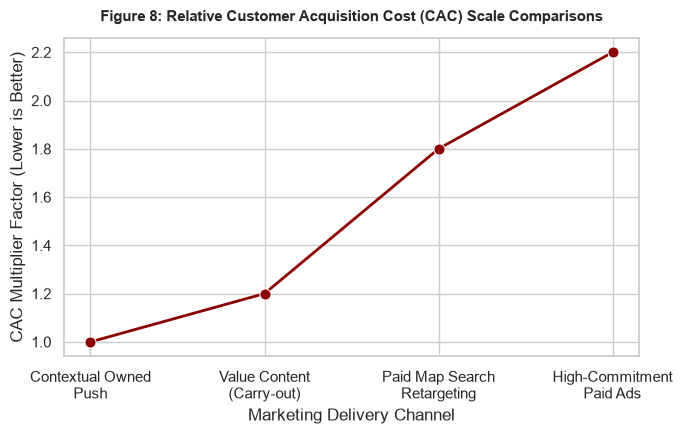

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_cac = pd.DataFrame({
    'Marketing Delivery Channel': ['Contextual Owned\nPush', 'Value Content\n(Carry-out)', 'Paid Map Search\nRetargeting', 'High-Commitment\nPaid Ads'],
    'Relative CAC Factor': [1.0, 1.2, 1.8, 2.2]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4.5))
sns.lineplot(x='Marketing Delivery Channel', y='Relative CAC Factor', data=df_cac, marker='o', color='darkred', lw=2, markersize=8)
plt.title('Figure 8: Relative Customer Acquisition Cost (CAC) Scale Comparisons', fontsize=11, fontweight='bold', pad=12)
plt.ylabel('CAC Multiplier Factor (Lower is Better)')
plt.tight_layout()
plt.show()